<a href="https://colab.research.google.com/github/DksMh/data-mining/blob/main/02_regression_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# STEP 1 — 라이브러리 + 데이터 로드
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

!apt-get install -y fonts-nanum -qq
import matplotlib.font_manager as fm
fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.family': 'NanumGothic', 'axes.unicode_minus': False})

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/데이터마이닝/analysis_ready.csv',
                 index_col=0, parse_dates=True)

print(f'✅ 데이터 로드: {df.shape}')
print(df.columns.tolist())

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
Mounted at /content/drive
✅ 데이터 로드: (230, 11)
['KODEX_반도체_ret', 'TIGER_200IT_ret', 'SOXX_KRW_ret', 'QQQ_KRW_ret', 'USDKRW_ret', 'SP500_ret', 'KOSPI_ret', 'VIX_ret', 'WTI_ret', 'AI_interest', 'phase']


In [ ]:
# STEP 2 — OLS 다중회귀분석 (H1-1 ~ H1-4 가설 검증)
import statsmodels.api as sm

X_COLS = ['USDKRW_ret','SP500_ret','KOSPI_ret','VIX_ret','WTI_ret','AI_interest']
X = sm.add_constant(df[X_COLS])

TARGETS = {
    'KODEX_반도체': 'KODEX_반도체_ret',
    'TIGER_200IT':  'TIGER_200IT_ret',
    'SOXX_KRW':     'SOXX_KRW_ret',
    'QQQ_KRW':      'QQQ_KRW_ret',
}

results = {}
for name, col in TARGETS.items():
    model = sm.OLS(df[col], X).fit()
    results[name] = model
    print(f'\n{"="*50}')
    print(f'  {name} — OLS 결과')
    print(f'{"="*50}')
    print(f'Adj. R²: {model.rsquared_adj:.4f}')
    print(f'관측치:  {model.nobs:.0f}')
    print(model.summary().tables[1])


  KODEX_반도체 — OLS 결과
Adj. R²: 0.5972
관측치:  230
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0025      0.003     -0.748      0.455      -0.009       0.004
USDKRW_ret     -0.0871      0.179     -0.487      0.627      -0.440       0.266
SP500_ret       0.2050      0.132      1.554      0.122      -0.055       0.465
KOSPI_ret       1.1325      0.085     13.348      0.000       0.965       1.300
VIX_ret         0.0116      0.019      0.611      0.542      -0.026       0.049
WTI_ret         0.0984      0.034      2.872      0.004       0.031       0.166
AI_interest     0.0001   8.52e-05      1.265      0.207   -6.01e-05       0.000

  TIGER_200IT — OLS 결과
Adj. R²: 0.3619
관측치:  230
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0011

In [ ]:
# ════════════════════════════════════════════════════════
# 기말 내용 부분 추가 (20260514)
# STEP 3 — 잔차 진단 — Durbin-Watson (자기상관) + Breusch-Pagan (이분산성)
# 교수님 보완 포인트: "잔차 진단이 수행되지 않아 p-value 신뢰도 보류"
# ════════════════════════════════════════════════════════

import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan

df = pd.read_csv('/content/drive/MyDrive/데이터마이닝/analysis_ready.csv',
                 index_col='date', parse_dates=True)

TARGETS = {
    'KODEX 반도체': 'KODEX_반도체_ret',
    'TIGER 200IT': 'TIGER_200IT_ret',
    'SOXX (원화)':  'SOXX_KRW_ret',
    'QQQ (원화)':   'QQQ_KRW_ret',
}

FORMULA = 'Q("{dep}") ~ USDKRW_ret + SP500_ret + KOSPI_ret + VIX_ret + WTI_ret + AI_interest'

print('=' * 62)
print(f'{"ETF":<14} {"DW 통계량":>10} {"자기상관":>10} {"BP p-value":>12} {"이분산성":>10}')
print('=' * 62)

results = {}
for name, col in TARGETS.items():
    model = smf.ols(FORMULA.format(dep=col), data=df).fit()

    # Durbin-Watson: 2에 가까울수록 자기상관 없음 (1.5~2.5 정상)
    dw = durbin_watson(model.resid)
    dw_판정 = '정상' if 1.5 <= dw <= 2.5 else '⚠️ 의심'

    # Breusch-Pagan: p < 0.05면 이분산성 존재
    bp_stat, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)
    bp_판정 = '⚠️ 존재' if bp_p < 0.05 else '정상'

    results[name] = {'model': model, 'dw': dw, 'bp_p': bp_p}
    print(f'{name:<14} {dw:>10.3f} {dw_판정:>10} {bp_p:>12.4f} {bp_판정:>10}')

print('=' * 62)
print('기준: DW 1.5~2.5 = 자기상관 없음 / BP p≥0.05 = 이분산성 없음')

diag_df = pd.DataFrame({k: {'DW': v['dw'], 'BP_p': v['bp_p']} for k, v in results.items()}).T
print('\n잔차 진단 요약표:')
print(diag_df.round(4))

ETF                DW 통계량       자기상관   BP p-value       이분산성
KODEX 반도체           2.038         정상       0.0263      ⚠️ 존재
TIGER 200IT         2.184         정상       0.0721         정상
SOXX (원화)           2.110         정상       0.9956         정상
QQQ (원화)            1.811         정상       0.1877         정상
기준: DW 1.5~2.5 = 자기상관 없음 / BP p≥0.05 = 이분산성 없음

잔차 진단 요약표:
                 DW    BP_p
KODEX 반도체    2.0377  0.0263
TIGER 200IT  2.1837  0.0721
SOXX (원화)    2.1103  0.9956
QQQ (원화)     1.8113  0.1877


In [ ]:
# ════════════════════════════════════════════════════════
# 기말 내용 부분 추가 (20260514)
# STEP 4 — Q2. SOXX β 분리 검증
# 교수 Q2: β(원화) − β(달러) ≈ 1 이면
# SOXX의 환율 민감도는 원화 환산 회계 효과임을 확인
# ════════════════════════════════════════════════════════

import statsmodels.formula.api as smf

# 달러 기준 SOXX 수익률 역산
# SOXX_KRW = (1 + SOXX_USD) * (1 + FX) - 1
# → SOXX_USD = (1 + SOXX_KRW) / (1 + FX) - 1
df['SOXX_USD_ret'] = (1 + df['SOXX_KRW_ret']) / (1 + df['USDKRW_ret']) - 1

FORMULA = '{dep} ~ USDKRW_ret + SP500_ret + KOSPI_ret + VIX_ret + WTI_ret + AI_interest'

# 원화 기준 OLS (기존 결과)
m_krw = smf.ols(FORMULA.format(dep='SOXX_KRW_ret'), data=df).fit()

# 달러 기준 OLS (신규)
m_usd = smf.ols(FORMULA.format(dep='SOXX_USD_ret'), data=df).fit()

b_krw = m_krw.params['USDKRW_ret']
b_usd = m_usd.params['USDKRW_ret']
p_krw = m_krw.pvalues['USDKRW_ret']
p_usd = m_usd.pvalues['USDKRW_ret']
diff  = b_krw - b_usd

print('=' * 52)
print('   SOXX 환율 β 분리 검증 (교수님 Q2)')
print('=' * 52)
print(f'  β (원화 기준): {b_krw:+.4f}   p={p_krw:.4f}')
print(f'  β (달러 기준): {b_usd:+.4f}   p={p_usd:.4f}')
print(f'  차이 β(원화) − β(달러): {diff:+.4f}')
print('=' * 52)

if abs(diff - 1.0) < 0.1:
    print('  ✅ 차이 ≈ 1 → 환율 β는 원화 환산 회계 효과')
else:
    print(f'  ⚠️ 차이 = {diff:.4f} → 추가 해석 필요')

#print(f'\n  해석: SOXX의 환율 β={b_krw:.3f}는')
#print(f'  달러 기준 β={b_usd:.3f}에 환산 효과 ≈1이 더해진 결과')
#print(f'  즉 "미국 반도체주의 환율 민감도"가 아닌')
#print(f'  "원화 환산 구조 자체의 회계 효과"임이 확인됨')

   SOXX 환율 β 분리 검증 (교수님 Q2)
  β (원화 기준): +1.0399   p=0.0000
  β (달러 기준): +0.0273   p=0.8591
  차이 β(원화) − β(달러): +1.0126
  ✅ 차이 ≈ 1 → 환율 β는 원화 환산 회계 효과


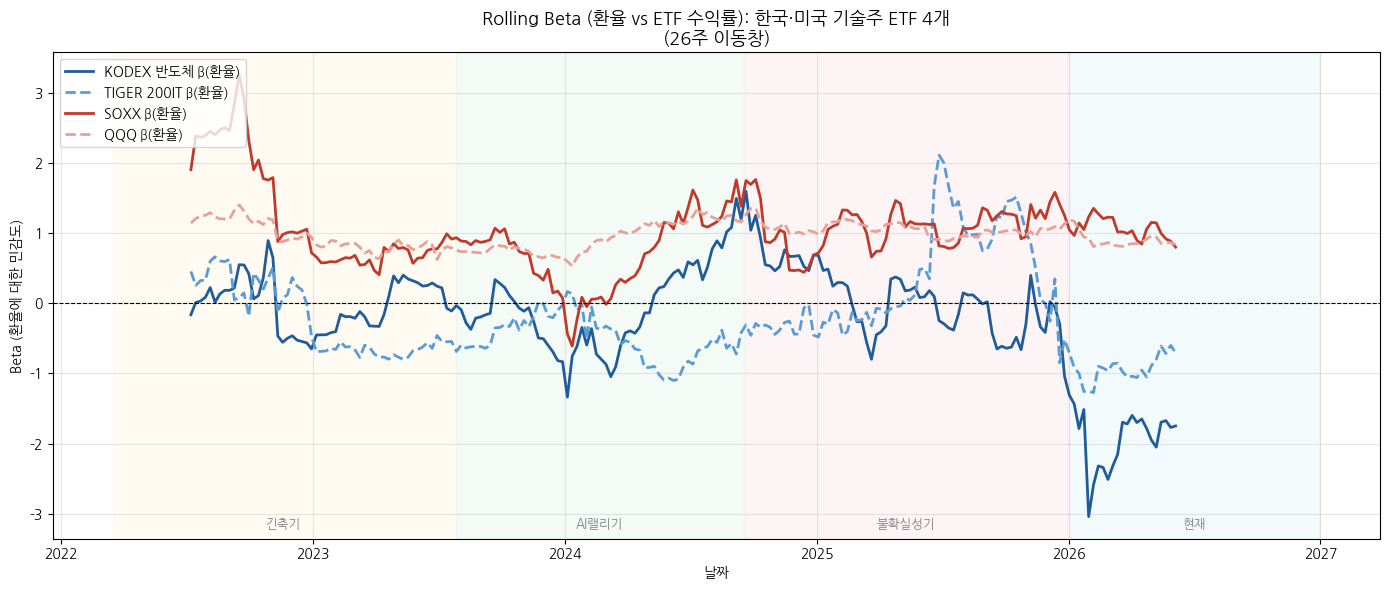

✅ Rolling Beta 4개 ETF 차트 저장 완료


In [ ]:
# Rolling Beta — 4개 ETF 전체 (환율 기준)
from statsmodels.regression.rolling import RollingOLS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm

WINDOW = 26

X_COLS = ['USDKRW_ret','SP500_ret','KOSPI_ret','VIX_ret','WTI_ret','AI_interest']
X = sm.add_constant(df[X_COLS])

PHASES = {
    '긴축기':     ('2022-03-17', '2023-07-26', '#FFF3CD'),
    'AI랠리기':   ('2023-07-27', '2024-09-17', '#D4EDDA'),
    '불확실성기': ('2024-09-18', '2025-12-31', '#F8D7DA'),
    '현재':       ('2026-01-01', '2026-12-31', '#D1ECF1'),
}

fig, ax = plt.subplots(figsize=(14, 6))

# ✅ 추가 1 — 4개 ETF Rolling Beta 계산
rols_kodex = RollingOLS(df['KODEX_반도체_ret'], X, window=WINDOW).fit()
beta_kodex = rols_kodex.params['USDKRW_ret']

rols_tiger = RollingOLS(df['TIGER_200IT_ret'], X, window=WINDOW).fit()  # 추가
beta_tiger = rols_tiger.params['USDKRW_ret']                            # 추가

rols_soxx = RollingOLS(df['SOXX_KRW_ret'], X, window=WINDOW).fit()
beta_soxx = rols_soxx.params['USDKRW_ret']

rols_qqq = RollingOLS(df['QQQ_KRW_ret'], X, window=WINDOW).fit()        # 추가
beta_qqq = rols_qqq.params['USDKRW_ret']                                # 추가

# 국면 배경
for phase, (start, end, color) in PHASES.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.25, color=color, label=f'_{phase}')

# ✅ 추가 2 — 4개 라인 플롯
ax.plot(beta_kodex.index, beta_kodex,
        color='#1F5C99', lw=2, label='KODEX 반도체 β(환율)')
ax.plot(beta_tiger.index, beta_tiger,
        color='#5B9BD5', lw=2, label='TIGER 200IT β(환율)', linestyle='--')  # 추가
ax.plot(beta_soxx.index, beta_soxx,
        color='#C0392B', lw=2, label='SOXX β(환율)')
ax.plot(beta_qqq.index, beta_qqq,
        color='#E8A09A', lw=2, label='QQQ β(환율)', linestyle='--')           # 추가

ax.axhline(0, color='black', lw=0.8, linestyle='--')

for phase, (start, end, color) in PHASES.items():
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, -3.2, phase, ha='center', fontsize=9, color='gray')

# ✅ 추가 3 — 제목 수정
ax.set_title('Rolling Beta (환율 vs ETF 수익률): 한국·미국 기술주 ETF 4개\n(26주 이동창)', fontsize=13)
ax.set_xlabel('날짜')
ax.set_ylabel('Beta (환율에 대한 민감도)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/rolling_beta_USDKRW_4ETF.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Rolling Beta 4개 ETF 차트 저장 완료')

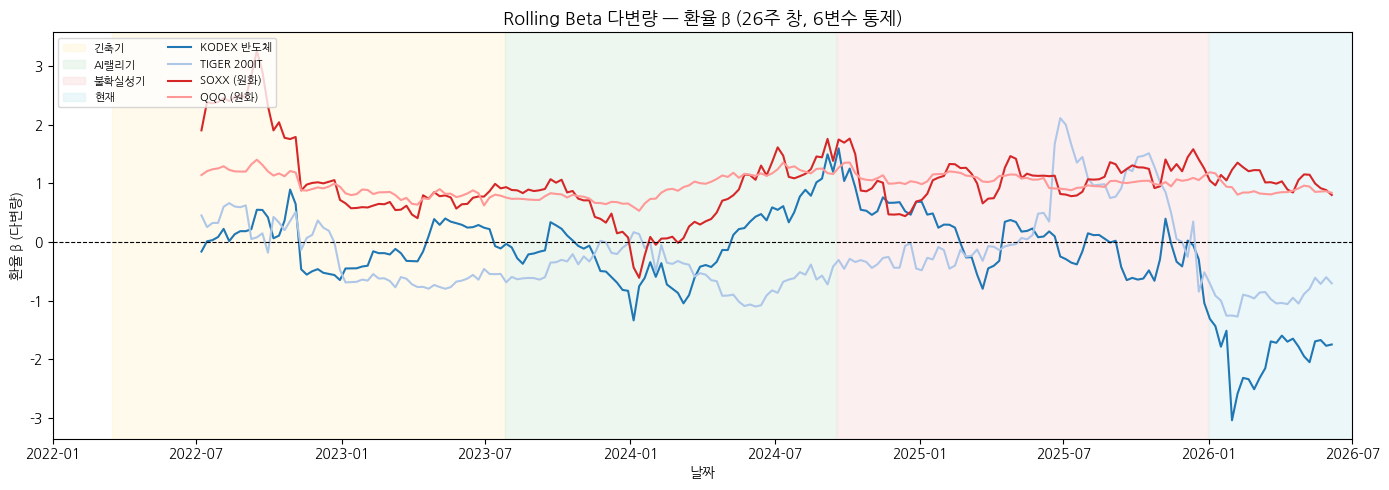

✅ 저장 완료: /content/drive/MyDrive/데이터마이닝/rolling_beta_multivariate.png

단변량 vs 다변량 환율 β 비교 (전체 기간 평균)
ETF                 단변량 β      다변량 β       차이
KODEX 반도체          -1.228     -0.210    1.018
TIGER 200IT        -1.070     -0.217    0.853
SOXX (원화)          -0.229      1.022    1.251
QQQ (원화)            0.210      0.976    0.765


In [ ]:
# ════════════════════════════════════════════════════════
# 기말 내용 부분 추가 (20260515)
# STEP 5 — Q1. Rolling Beta 다변량 전환
# 교수 Q1: 6변수 OLS에서 환율 β만 26주 창 추출
# 단변량 대비 KODEX β=−3 극단값 유지 여부 확인
# ════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

WINDOW = 26
TARGETS = {
    'KODEX 반도체': 'KODEX_반도체_ret',
    'TIGER 200IT':  'TIGER_200IT_ret',
    'SOXX (원화)':  'SOXX_KRW_ret',
    'QQQ (원화)':   'QQQ_KRW_ret',
}
X_COLS = ['USDKRW_ret', 'SP500_ret', 'KOSPI_ret', 'VIX_ret', 'WTI_ret', 'AI_interest']

df_clean = df.dropna(subset=X_COLS + list(TARGETS.values()))
X = sm.add_constant(df_clean[X_COLS])

# 26주 창 롤링 — 환율 β만 추출
rolling_betas = {}
for name, col in TARGETS.items():
    betas = [np.nan] * len(df_clean)
    for i in range(WINDOW, len(df_clean) + 1):
        X_w = X.iloc[i - WINDOW:i]
        y_w = df_clean[col].iloc[i - WINDOW:i]
        try:
            res = sm.OLS(y_w, X_w).fit()
            betas[i - 1] = res.params['USDKRW_ret']
        except:
            pass
    rolling_betas[name] = betas

beta_df = pd.DataFrame(rolling_betas, index=df_clean.index)

# ── 시각화 ──────────────────────────────────────────────
PHASES = {
    '긴축기':     ('2022-03-17', '2023-07-26', '#fff3cd'),
    'AI랠리기':   ('2023-07-27', '2024-09-17', '#d4edda'),
    '불확실성기': ('2024-09-18', '2025-12-31', '#f8d7da'),
    '현재':       ('2026-01-01', '2099-12-31', '#d1ecf1'),
}
COLORS = {
    'KODEX 반도체': '#1f77b4',
    'TIGER 200IT':  '#aec7e8',
    'SOXX (원화)':  '#d62728',
    'QQQ (원화)':   '#ff9896',
}

fig, ax = plt.subplots(figsize=(14, 5))

for phase, (s, e, c) in PHASES.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=c, alpha=0.4, label=phase)

for name, col in TARGETS.items():
    ax.plot(beta_df.index, beta_df[name], label=name,
            color=COLORS[name], linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlim(pd.Timestamp('2022-01-01'), pd.Timestamp('2026-07-01'))  # ← 추가
ax.set_title('Rolling Beta 다변량 — 환율 β (26주 창, 6변수 통제)', fontsize=13)
ax.set_ylabel('환율 β (다변량)')
ax.set_xlabel('날짜')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()

save_path = '/content/drive/MyDrive/데이터마이닝/rolling_beta_multivariate.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'✅ 저장 완료: {save_path}')

# ── 단변량 vs 다변량 수치 비교 ──────────────────────────
print('\n단변량 vs 다변량 환율 β 비교 (전체 기간 평균)')
print('=' * 52)
print(f'{"ETF":<14} {"단변량 β":>10} {"다변량 β":>10} {"차이":>8}')
print('=' * 52)

uni_betas = {}
for name, col in TARGETS.items():
    b = sm.OLS(df_clean[col],
               sm.add_constant(df_clean['USDKRW_ret'])).fit().params['USDKRW_ret']
    uni_betas[name] = b

for name in TARGETS:
    u = uni_betas[name]
    m = beta_df[name].mean()
    print(f'{name:<14} {u:>10.3f} {m:>10.3f} {m-u:>8.3f}')
print('=' * 52)

In [ ]:
# ════════════════════════════════════════════════════════
# 기말 내용 부분 추가 (20260518)
# STEP 6 — Q3. AI_interest mediator 분해
# 교수 Q3: 시장지수 포함 vs 제외 모델 β 비교
# → AI관심도의 직접효과 vs 간접효과(시장지수 매개) 분리
# 학생 질문(장진원): 단변량 신호가 다변량에서 사라진 이유
# ════════════════════════════════════════════════════════

import statsmodels.formula.api as smf
import pandas as pd

TARGETS = {
    'KODEX 반도체': 'KODEX_반도체_ret',
    'TIGER 200IT':  'TIGER_200IT_ret',
    'SOXX (원화)':  'SOXX_KRW_ret',
    'QQQ (원화)':   'QQQ_KRW_ret',
}

# 모델 A: 시장지수 포함 (기존 전체 모델)
FORMULA_FULL = '{dep} ~ USDKRW_ret + SP500_ret + KOSPI_ret + VIX_ret + WTI_ret + AI_interest'

# 모델 B: 시장지수 제외 (SP500, KOSPI 빼기)
FORMULA_NO_MKT = '{dep} ~ USDKRW_ret + VIX_ret + WTI_ret + AI_interest'

print('=' * 68)
print(f'{"ETF":<14} {"β_포함":>8} {"p_포함":>8} {"β_제외":>8} {"p_제외":>8} {"변화":>8}')
print('  (시장지수 포함 모델 vs 제외 모델, AI_interest 계수 비교)')
print('=' * 68)

mediation_results = {}
for name, col in TARGETS.items():
    m_full    = smf.ols(FORMULA_FULL.format(dep=col),    data=df).fit()
    m_no_mkt  = smf.ols(FORMULA_NO_MKT.format(dep=col), data=df).fit()

    b_full   = m_full.params['AI_interest']
    p_full   = m_full.pvalues['AI_interest']
    b_no_mkt = m_no_mkt.params['AI_interest']
    p_no_mkt = m_no_mkt.pvalues['AI_interest']
    delta    = b_no_mkt - b_full  # 시장지수 제거 후 β 변화량

    mediation_results[name] = {
        'β_포함': b_full, 'p_포함': p_full,
        'β_제외': b_no_mkt, 'p_제외': p_no_mkt,
        '변화': delta
    }
    print(f'{name:<14} {b_full:>8.4f} {p_full:>8.4f} {b_no_mkt:>8.4f} {p_no_mkt:>8.4f} {delta:>+8.4f}')

print('=' * 68)
print('해석 기준: β_제외 > β_포함 → 시장지수가 AI_interest 효과를 매개(mediator)')
print('           β_제외 ≈ β_포함 → 시장지수와 무관한 직접 효과')

# ── 선택: lag 1~2주 보조 분석 (박기원 제안) ─────────────
print('\n\n[보조] AI_interest lag 1~2주 — 선행지표 가능성 검토')
print('=' * 68)

df['AI_interest_lag1'] = df['AI_interest'].shift(1)
df['AI_interest_lag2'] = df['AI_interest'].shift(2)

FORMULA_LAG1 = '{dep} ~ USDKRW_ret + SP500_ret + KOSPI_ret + VIX_ret + WTI_ret + AI_interest_lag1'
FORMULA_LAG2 = '{dep} ~ USDKRW_ret + SP500_ret + KOSPI_ret + VIX_ret + WTI_ret + AI_interest_lag2'

print(f'{"ETF":<14} {"β_lag1":>8} {"p_lag1":>8} {"β_lag2":>8} {"p_lag2":>8}')
print('-' * 68)

for name, col in TARGETS.items():
    m1 = smf.ols(FORMULA_LAG1.format(dep=col), data=df.dropna()).fit()
    m2 = smf.ols(FORMULA_LAG2.format(dep=col), data=df.dropna()).fit()
    b1, p1 = m1.params['AI_interest_lag1'], m1.pvalues['AI_interest_lag1']
    b2, p2 = m2.params['AI_interest_lag2'], m2.pvalues['AI_interest_lag2']
    print(f'{name:<14} {b1:>8.4f} {p1:>8.4f} {b2:>8.4f} {p2:>8.4f}')

print('=' * 68)
print('p < 0.05이면 AI관심도가 선행지표로서 유의 / p ≥ 0.05이면 기각 유지')

ETF                β_포함     p_포함     β_제외     p_제외       변화
  (시장지수 포함 모델 vs 제외 모델, AI_interest 계수 비교)
KODEX 반도체        0.0001   0.2073   0.0006   0.0000  +0.0005
TIGER 200IT     -0.0001   0.2720   0.0002   0.0403  +0.0003
SOXX (원화)        0.0001   0.4111   0.0004   0.0002  +0.0003
QQQ (원화)         0.0000   0.7452   0.0001   0.0114  +0.0001
해석 기준: β_제외 > β_포함 → 시장지수가 AI_interest 효과를 매개(mediator)
           β_제외 ≈ β_포함 → 시장지수와 무관한 직접 효과


[보조] AI_interest lag 1~2주 — 선행지표 가능성 검토
ETF              β_lag1   p_lag1   β_lag2   p_lag2
--------------------------------------------------------------------
KODEX 반도체        0.0001   0.2545   0.0001   0.2322
TIGER 200IT     -0.0001   0.2667  -0.0001   0.2610
SOXX (원화)        0.0001   0.4380   0.0001   0.4334
QQQ (원화)         0.0000   0.9064   0.0000   0.9664
p < 0.05이면 AI관심도가 선행지표로서 유의 / p ≥ 0.05이면 기각 유지


현재 국면 표본 수: 23주
기간: 2026-01-02 ~ 2026-06-05

  Bootstrap 결과 (현재 국면, n=1000회)
  Bootstrap 평균 β:  -1.6555
  95% CI:            [-3.9562, 0.8946]
  ⚠️ CI가 0을 포함 → 불안정 가능성
  ※ 소표본(n=23) 기반 Bootstrap CI는 근사치임에 유의


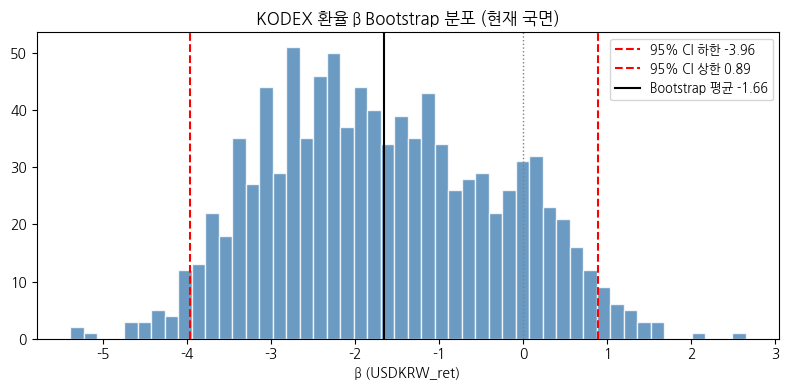


  Leave-one-week-out 결과
  β 범위: [-2.2848, -0.1612]
  β 평균: -1.6495
  ✅ 어떤 주를 빼도 β<0 → 특정 이상치 의존 없음
  ※ n-1=22주 기반 추정이므로 계수 분산이 클 수 있음


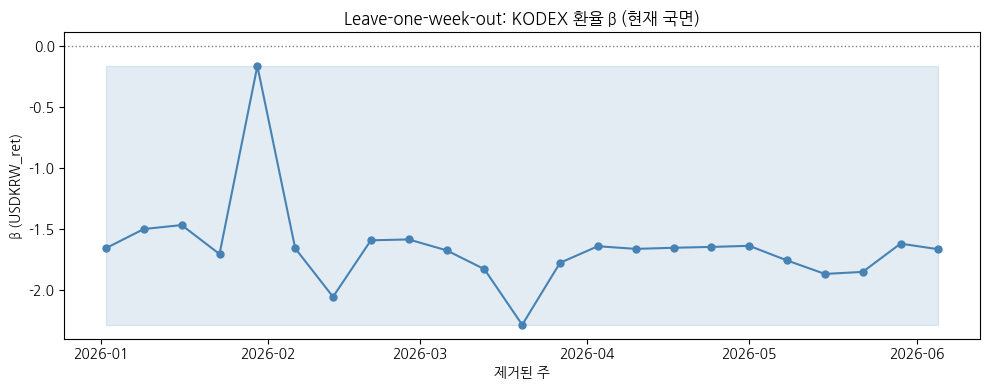

✅ 저장 완료


In [ ]:
# ════════════════════════════════════════════════════════
# 기말 내용 부분 추가 (20260527)
# STEP 7 — Q4. KODEX β=−3 Bootstrap robustness
# 교수 Q4: "현재" 국면 19주 소표본에서 β=−3이
# 우연이 아닌 구조적 변화임을 검증
# 방법 1: Bootstrap 95% CI (1000회 재표본)
# 방법 2: Leave-one-week-out 안정성 검사
# ════════════════════════════════════════════════════════

import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

X_COLS = ['USDKRW_ret', 'SP500_ret', 'KOSPI_ret',
          'VIX_ret', 'WTI_ret', 'AI_interest']

# 현재 국면 데이터만 추출
df_now = df[df['phase'] == '현재'].dropna(subset=X_COLS + ['KODEX_반도체_ret'])
#X_now  = sm.add_constant(df_now[X_COLS]).values
X_now_df = sm.add_constant(df_now[X_COLS])  # DataFrame 유지
y_now  = df_now['KODEX_반도체_ret'].values
n      = len(df_now)

print(f'현재 국면 표본 수: {n}주')
print(f'기간: {df_now.index[0].date()} ~ {df_now.index[-1].date()}\n')

# ── 방법 1: Bootstrap CI ─────────────────────────────
np.random.seed(42)
N_BOOT = 1000
boot_betas = []

for _ in range(N_BOOT):
    idx = np.random.choice(n, size=n, replace=True)
    try:
        res = sm.OLS(y_now[idx], X_now_df.iloc[idx]).fit()
        boot_betas.append(res.params['USDKRW_ret'])  # 이름으로 접근
    except:
        pass

boot_betas = np.array(boot_betas)
ci_low, ci_high = np.percentile(boot_betas, [2.5, 97.5])
boot_mean = np.mean(boot_betas)

print('=' * 52)
print('  Bootstrap 결과 (현재 국면, n=1000회)')
print('=' * 52)
print(f'  Bootstrap 평균 β:  {boot_mean:.4f}')
print(f'  95% CI:            [{ci_low:.4f}, {ci_high:.4f}]')
if ci_high < 0:
    print('  ✅ CI 전체가 0 미만 → β<0 강건하게 유지')
else:
    print('  ⚠️ CI가 0을 포함 → 불안정 가능성')
print(f'  ※ 소표본(n={n}) 기반 Bootstrap CI는 근사치임에 유의')
print('=' * 52)

# Bootstrap 분포 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_betas, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(ci_low,    color='red',   linestyle='--', label=f'95% CI 하한 {ci_low:.2f}')
ax.axvline(ci_high,   color='red',   linestyle='--', label=f'95% CI 상한 {ci_high:.2f}')
ax.axvline(boot_mean, color='black', linestyle='-',  label=f'Bootstrap 평균 {boot_mean:.2f}')
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_title('KODEX 환율 β Bootstrap 분포 (현재 국면)')
ax.set_xlabel('β (USDKRW_ret)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/bootstrap_CI_KODEX.png', dpi=150)
plt.show()

# ── 방법 2: Leave-one-week-out ───────────────────────
loo_betas = []
for i in range(n):
    idx = [j for j in range(n) if j != i]
    try:
        res = sm.OLS(y_now[idx], X_now_df.iloc[idx]).fit()
        loo_betas.append(res.params['USDKRW_ret'])  # 이름으로 접근
    except:
        loo_betas.append(np.nan)

loo_betas = np.array(loo_betas)
loo_min  = np.nanmin(loo_betas)
loo_max  = np.nanmax(loo_betas)
loo_mean = np.nanmean(loo_betas)

print('\n' + '=' * 52)
print('  Leave-one-week-out 결과')
print('=' * 52)
print(f'  β 범위: [{loo_min:.4f}, {loo_max:.4f}]')
print(f'  β 평균: {loo_mean:.4f}')
if loo_max < 0:
    print('  ✅ 어떤 주를 빼도 β<0 → 특정 이상치 의존 없음')
else:
    print('  ⚠️ 일부 주 제거 시 β≥0 → 특정 주에 의존')
print(f'  ※ n-1={n-1}주 기반 추정이므로 계수 분산이 클 수 있음')
print('=' * 52)

# LOO 시각화
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_now.index, loo_betas, marker='o', color='steelblue',
        linewidth=1.5, markersize=5)
ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.fill_between(df_now.index, loo_min, loo_max,
                alpha=0.15, color='steelblue')
ax.set_title('Leave-one-week-out: KODEX 환율 β (현재 국면)')
ax.set_ylabel('β (USDKRW_ret)')
ax.set_xlabel('제거된 주')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/loo_KODEX.png', dpi=150)
plt.show()
print('✅ 저장 완료')

  국면별 OLS — 환율 β (USDKRW_ret)
ETF                 긴축기          AI랠리기         불확실성기           현재     
                    β      p        β      p        β      p        β      p  
----------------------------------------------------------------------
KODEX 반도체       -0.12  0.583    0.59  0.220   -0.25  0.483   -1.65  0.079 
TIGER 200IT     -0.49  0.024★   -0.57  0.125    0.52  0.232   -0.95  0.283 
SOXX (원화)        0.86  0.000★    1.04  0.015★    1.02  0.000★    0.71  0.301 
QQQ (원화)         0.89  0.000★    1.11  0.000★    1.03  0.000★    0.85  0.000★ 
★ p<0.05

  Chow Test — 인접 국면 간 구조 변화 검정
ETF            국면 쌍                       F통계량       p값       판정
----------------------------------------------------------------------
KODEX 반도체      긴축기→AI랠리기                 3.178   0.0041   ★ 구조변화
KODEX 반도체      AI랠리기→불확실성기               1.703   0.1152       유지
KODEX 반도체      불확실성기→현재                  1.650   0.1344       유지

TIGER 200IT    긴축기→AI랠리기                 0.900   0.5089       유지
TIG

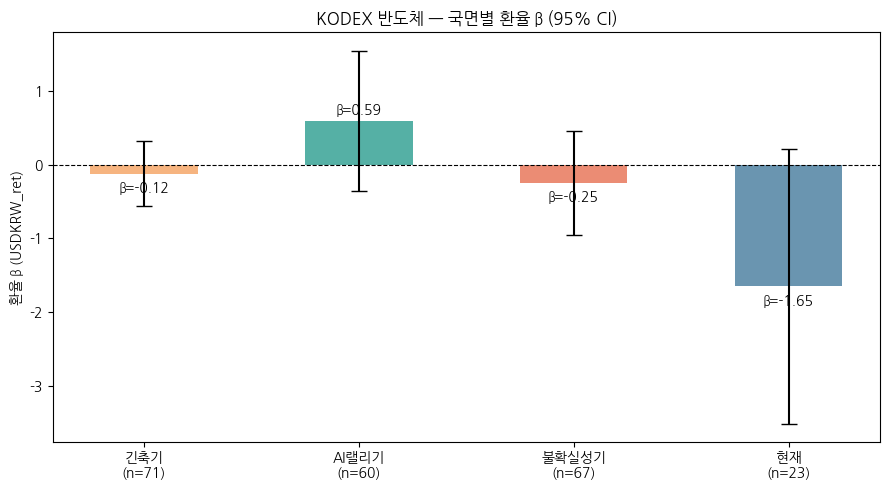

✅ 저장 완료


In [ ]:
# ════════════════════════════════════════════════════════
# 기말 내용 부분 추가 (20260528)
# STEP 8 — 국면별 OLS + Chow Test
# 목적: 시장 국면 간 회귀계수 구조 변화가
#       통계적으로 유의한지 검정
# Chow Test: 인접 국면 쌍별 구조 변화 검정
# ════════════════════════════════════════════════════════

import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

X_COLS  = ['USDKRW_ret', 'SP500_ret', 'KOSPI_ret',
           'VIX_ret', 'WTI_ret', 'AI_interest']
TARGETS = {
    'KODEX 반도체': 'KODEX_반도체_ret',
    'TIGER 200IT':  'TIGER_200IT_ret',
    'SOXX (원화)':  'SOXX_KRW_ret',
    'QQQ (원화)':   'QQQ_KRW_ret',
}
PHASES  = ['긴축기', 'AI랠리기', '불확실성기', '현재']
k       = len(X_COLS) + 1  # 상수항 포함 파라미터 수

# ── 1. 국면별 OLS — 환율 β 추출 ─────────────────────
print('=' * 70)
print('  국면별 OLS — 환율 β (USDKRW_ret)')
print('=' * 70)
print(f'{"ETF":<14}', end='')
for p in PHASES:
    print(f'  {p:^12}', end='')
print()
print(f'{"":14}', end='')
for p in PHASES:
    print(f'  {"β":>5} {"p":>6}  ', end='')
print()
print('-' * 70)

phase_models = {name: {} for name in TARGETS}

for name, col in TARGETS.items():
    print(f'{name:<14}', end='')
    for phase in PHASES:
        df_p = df[df['phase'] == phase].dropna(subset=X_COLS + [col])
        if len(df_p) < k + 2:
            print(f'  {"N/A":>5} {"N/A":>6}  ', end='')
            continue
        m = smf.ols(
            f'Q("{col}") ~ USDKRW_ret + SP500_ret + KOSPI_ret + VIX_ret + WTI_ret + AI_interest',
            data=df_p
        ).fit()
        b     = m.params['USDKRW_ret']
        p_val = m.pvalues['USDKRW_ret']
        sig   = '★' if p_val < 0.05 else ''
        phase_models[name][phase] = m
        print(f'  {b:>5.2f} {p_val:>6.3f}{sig} ', end='')
    print()

print('=' * 70)
print('★ p<0.05\n')

# ── 2. Chow Test — 인접 국면 쌍별 ───────────────────
def chow_test(df_all, col, phase_a, phase_b):
    """두 국면 간 Chow Test: F통계량, p값 반환"""
    df_a    = df_all[df_all['phase'] == phase_a].dropna(subset=X_COLS + [col])
    df_b    = df_all[df_all['phase'] == phase_b].dropna(subset=X_COLS + [col])
    df_pool = pd.concat([df_a, df_b])

    if len(df_a) < k + 2 or len(df_b) < k + 2:
        return np.nan, np.nan

    n = len(df_pool)
    if n <= 2 * k:                        # 자유도 부족 방어
        return np.nan, np.nan

    X_a    = sm.add_constant(df_a[X_COLS])
    X_b    = sm.add_constant(df_b[X_COLS])
    X_pool = sm.add_constant(df_pool[X_COLS])

    rss_a    = sm.OLS(df_a[col],    X_a).fit().ssr
    rss_b    = sm.OLS(df_b[col],    X_b).fit().ssr
    rss_pool = sm.OLS(df_pool[col], X_pool).fit().ssr

    F     = ((rss_pool - (rss_a + rss_b)) / k) / \
            ((rss_a + rss_b) / (n - 2 * k))
    F     = max(F, 0)                     # 수치 오차로 F<0 방지
    p_val = 1 - stats.f.cdf(F, k, n - 2 * k)
    return F, p_val

PAIRS = [('긴축기',    'AI랠리기'),
         ('AI랠리기',  '불확실성기'),
         ('불확실성기', '현재')]

print('=' * 70)
print('  Chow Test — 인접 국면 간 구조 변화 검정')
print('=' * 70)
print(f'{"ETF":<14} {"국면 쌍":<20} {"F통계량":>10} {"p값":>8} {"판정":>8}')
print('-' * 70)

for name, col in TARGETS.items():
    for pa, pb in PAIRS:
        F, p_val = chow_test(df, col, pa, pb)
        if np.isnan(F):
            print(f'{name:<14} {pa+"→"+pb:<20} {"N/A":>10} {"N/A":>8}')
            continue
        sig = '★ 구조변화' if p_val < 0.05 else '유지'
        print(f'{name:<14} {pa+"→"+pb:<20} {F:>10.3f} {p_val:>8.4f} {sig:>8}')
    print()

print('=' * 70)
print('★ p<0.05: 해당 국면 전환 시점에 구조적 변화 존재')
print('\n[해석 주의사항]')
print('① 현재 국면 n=21로 소표본이므로 F값 분산이 클 수 있음')
print('② ETF 4개 × 국면쌍 3개 = 12개 동시 검정으로')
print('   p<0.05 결과는 탐색적 증거(exploratory evidence) 수준으로 해석')

# ── 3. KODEX 환율 β 국면별 시각화 ───────────────────
kodex_col = TARGETS['KODEX 반도체']
betas, cis, labels = [], [], []

for phase in PHASES:
    df_p = df[df['phase'] == phase].dropna(subset=X_COLS + [kodex_col])
    if phase not in phase_models['KODEX 반도체']:
        continue
    m   = phase_models['KODEX 반도체'][phase]
    b   = m.params['USDKRW_ret']
    ci  = m.conf_int().loc['USDKRW_ret']
    betas.append(b)
    cis.append(ci)
    labels.append(f'{phase}\n(n={len(df_p)})')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#f4a261', '#2a9d8f', '#e76f51', '#457b9d']
for i, (b, ci, lab) in enumerate(zip(betas, cis, labels)):
    ax.bar(i, b, color=colors[i], alpha=0.8, width=0.5)
    ax.errorbar(i, b, yerr=[[b - ci[0]], [ci[1] - b]],
                fmt='none', color='black', capsize=6, linewidth=1.5)
    ax.text(i, b + (0.1 if b >= 0 else -0.25),
            f'β={b:.2f}', ha='center', fontsize=10)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('환율 β (USDKRW_ret)')
ax.set_title('KODEX 반도체 — 국면별 환율 β (95% CI)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/chow_KODEX_phase_beta.png', dpi=150)
plt.show()
print('✅ 저장 완료')

In [ ]:
# 기술통계량
desc = df.describe().T[['count','mean','std','min','50%','max']]
desc.columns = ['관측치수','평균','표준편차','최솟값','중앙값','최댓값']
desc = desc.round(4)

print("=== 기술통계량 ===")
print(desc.to_string())
desc.to_csv('/content/drive/MyDrive/데이터마이닝/descriptive_stats.csv', encoding='utf-8-sig')
print('✅ 기술통계량 저장 완료')

=== 기술통계량 ===
                   관측치수       평균     표준편차     최솟값      중앙값       최댓값
KODEX_반도체_ret     230.0   0.0074   0.0471 -0.1131   0.0046    0.2216
TIGER_200IT_ret   230.0  -0.0009   0.0373 -0.1123  -0.0031    0.1945
SOXX_KRW_ret      230.0   0.0072   0.0455 -0.1710   0.0043    0.1221
QQQ_KRW_ret       230.0   0.0043   0.0287 -0.1042   0.0069    0.0822
USDKRW_ret        230.0   0.0011   0.0126 -0.0522   0.0006    0.0329
SP500_ret         230.0   0.0023   0.0233 -0.0908   0.0032    0.0658
KOSPI_ret         230.0   0.0049   0.0296 -0.1056   0.0033    0.1363
VIX_ret           230.0   0.0113   0.1567 -0.3172  -0.0083    1.0928
WTI_ret           230.0   0.0022   0.0582 -0.1342   0.0036    0.3563
AI_interest       230.0  33.9000  25.2480  5.0000  28.0000  100.0000
SOXX_USD_ret      230.0   0.0062   0.0480 -0.1646   0.0062    0.1495
AI_interest_lag1  229.0  33.7205  25.1558  5.0000  28.0000  100.0000
AI_interest_lag2  228.0  33.5395  25.0612  5.0000  28.0000  100.0000
✅ 기술통계량 저장 완료


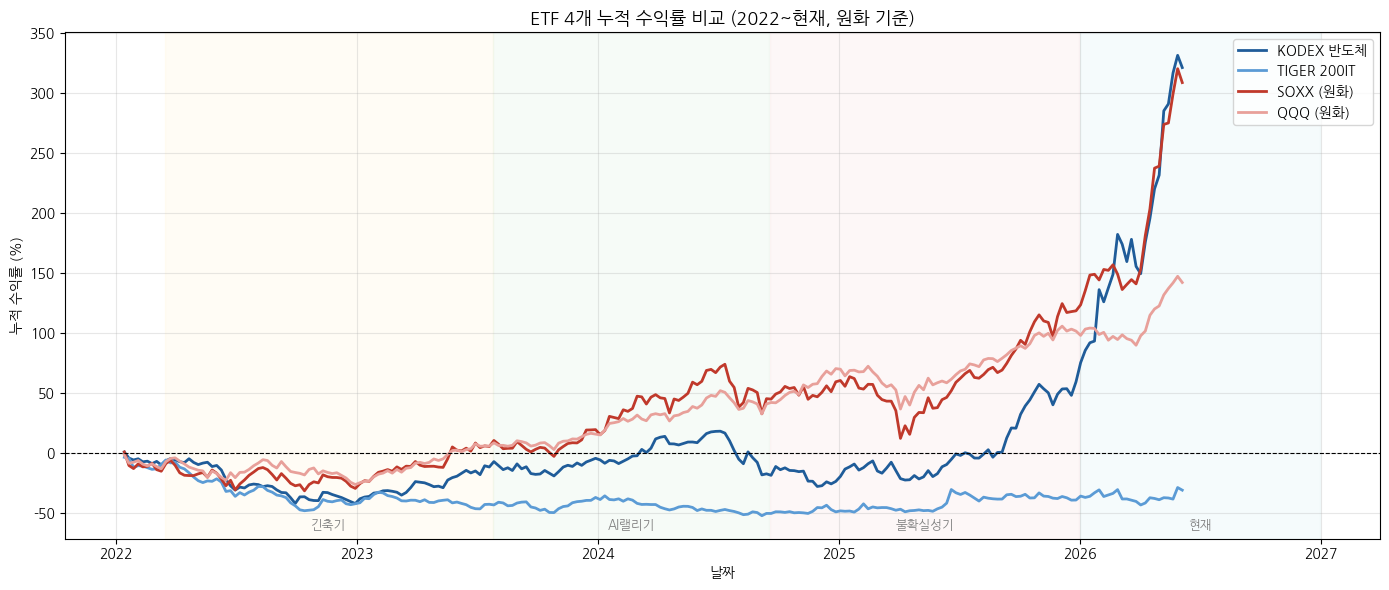

✅ 누적 수익률 저장 완료


In [ ]:
# 누적 수익률 차트
fig, ax = plt.subplots(figsize=(14, 6))

etf_cols = {
    'KODEX 반도체': 'KODEX_반도체_ret',
    'TIGER 200IT':  'TIGER_200IT_ret',
    'SOXX (원화)':  'SOXX_KRW_ret',
    'QQQ (원화)':   'QQQ_KRW_ret',
}
colors = ['#1F5C99','#5B9BD5','#C0392B','#E8A09A']

for (name, col), color in zip(etf_cols.items(), colors):
    cumret = (1 + df[col]).cumprod() - 1
    ax.plot(cumret.index, cumret * 100, label=name, color=color, lw=2)

PHASES = {
    '긴축기':     ('2022-03-17','2023-07-26','#FFF3CD'),
    'AI랠리기':   ('2023-07-27','2024-09-17','#D4EDDA'),
    '불확실성기': ('2024-09-18','2025-12-31','#F8D7DA'),
    '현재':       ('2026-01-01','2026-12-31','#D1ECF1'),
}
for phase, (s, e, c) in PHASES.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.2, color=c)
    mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
    ax.text(mid, 0.02, phase,
            transform=ax.get_xaxis_transform(),
            ha='center', fontsize=9, color='gray')

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_title('ETF 4개 누적 수익률 비교 (2022~현재, 원화 기준)', fontsize=13)
ax.set_xlabel('날짜')
ax.set_ylabel('누적 수익률 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 누적 수익률 저장 완료')

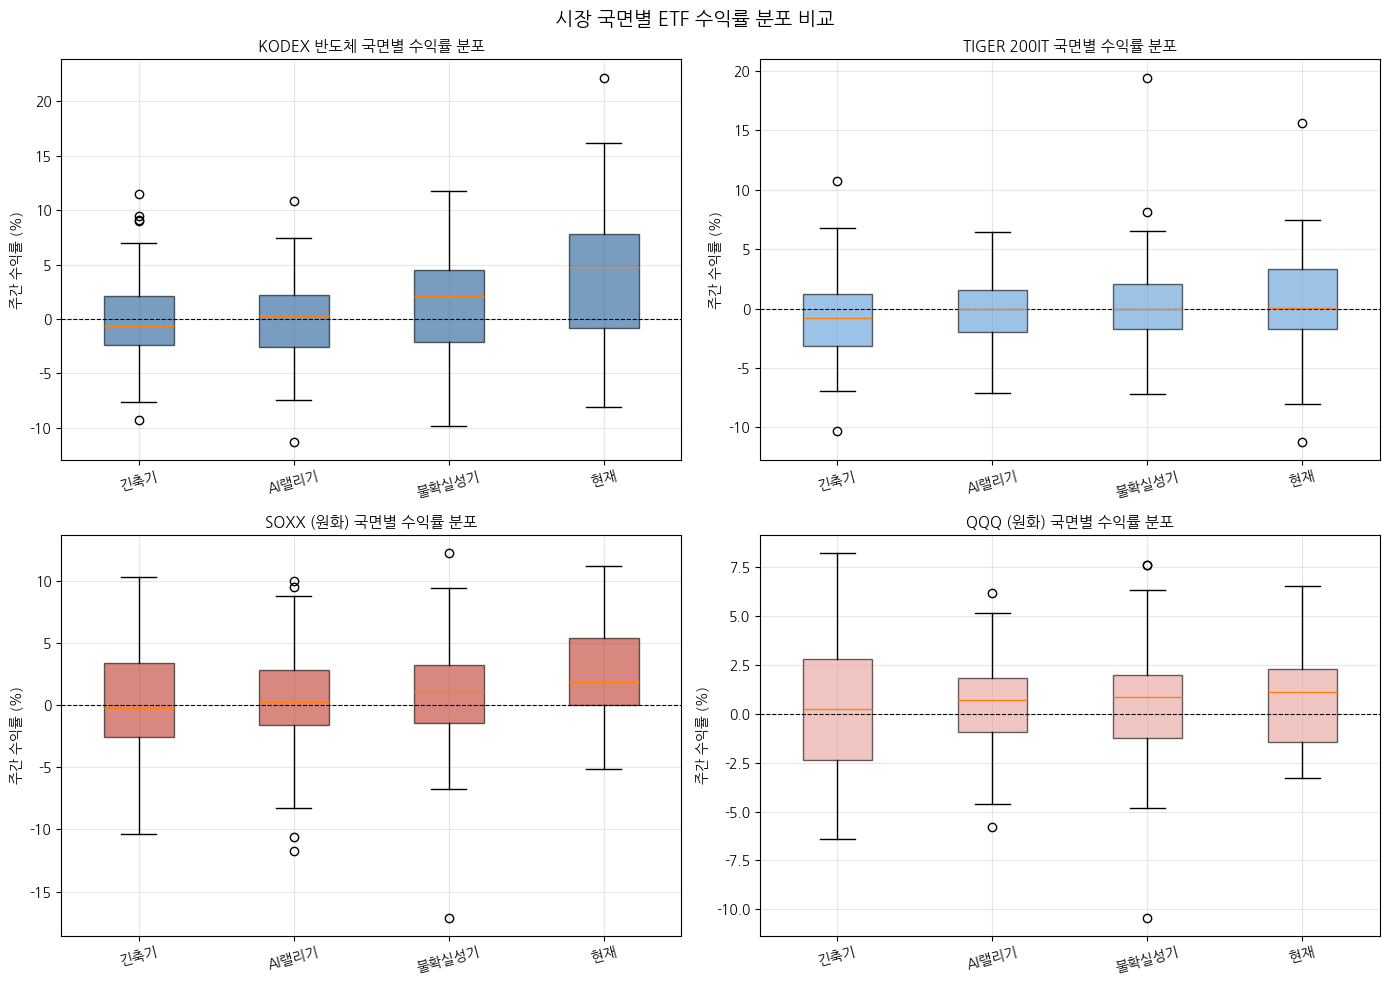

✅ Boxplot 저장 완료


In [ ]:
# 국면별 Boxplot (기타 제외, 4개 ETF 전체)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

etf_list = [
    ('KODEX 반도체', 'KODEX_반도체_ret', '#1F5C99'),
    ('TIGER 200IT',  'TIGER_200IT_ret',  '#5B9BD5'),
    ('SOXX (원화)',  'SOXX_KRW_ret',     '#C0392B'),
    ('QQQ (원화)',   'QQQ_KRW_ret',      '#E8A09A'),
]

# 기타 제외
phase_order = ['긴축기','AI랠리기','불확실성기','현재']
df_plot = df[df['phase'] != '기타']

for ax, (name, col, color) in zip(axes.flatten(), etf_list):
    data = [df_plot[df_plot['phase']==p][col].dropna() * 100
            for p in phase_order]
    bp = ax.boxplot(data, labels=phase_order, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title(f'{name} 국면별 수익률 분포', fontsize=11)
    ax.set_ylabel('주간 수익률 (%)')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, alpha=0.3)

plt.suptitle('시장 국면별 ETF 수익률 분포 비교', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/boxplot_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Boxplot 저장 완료')

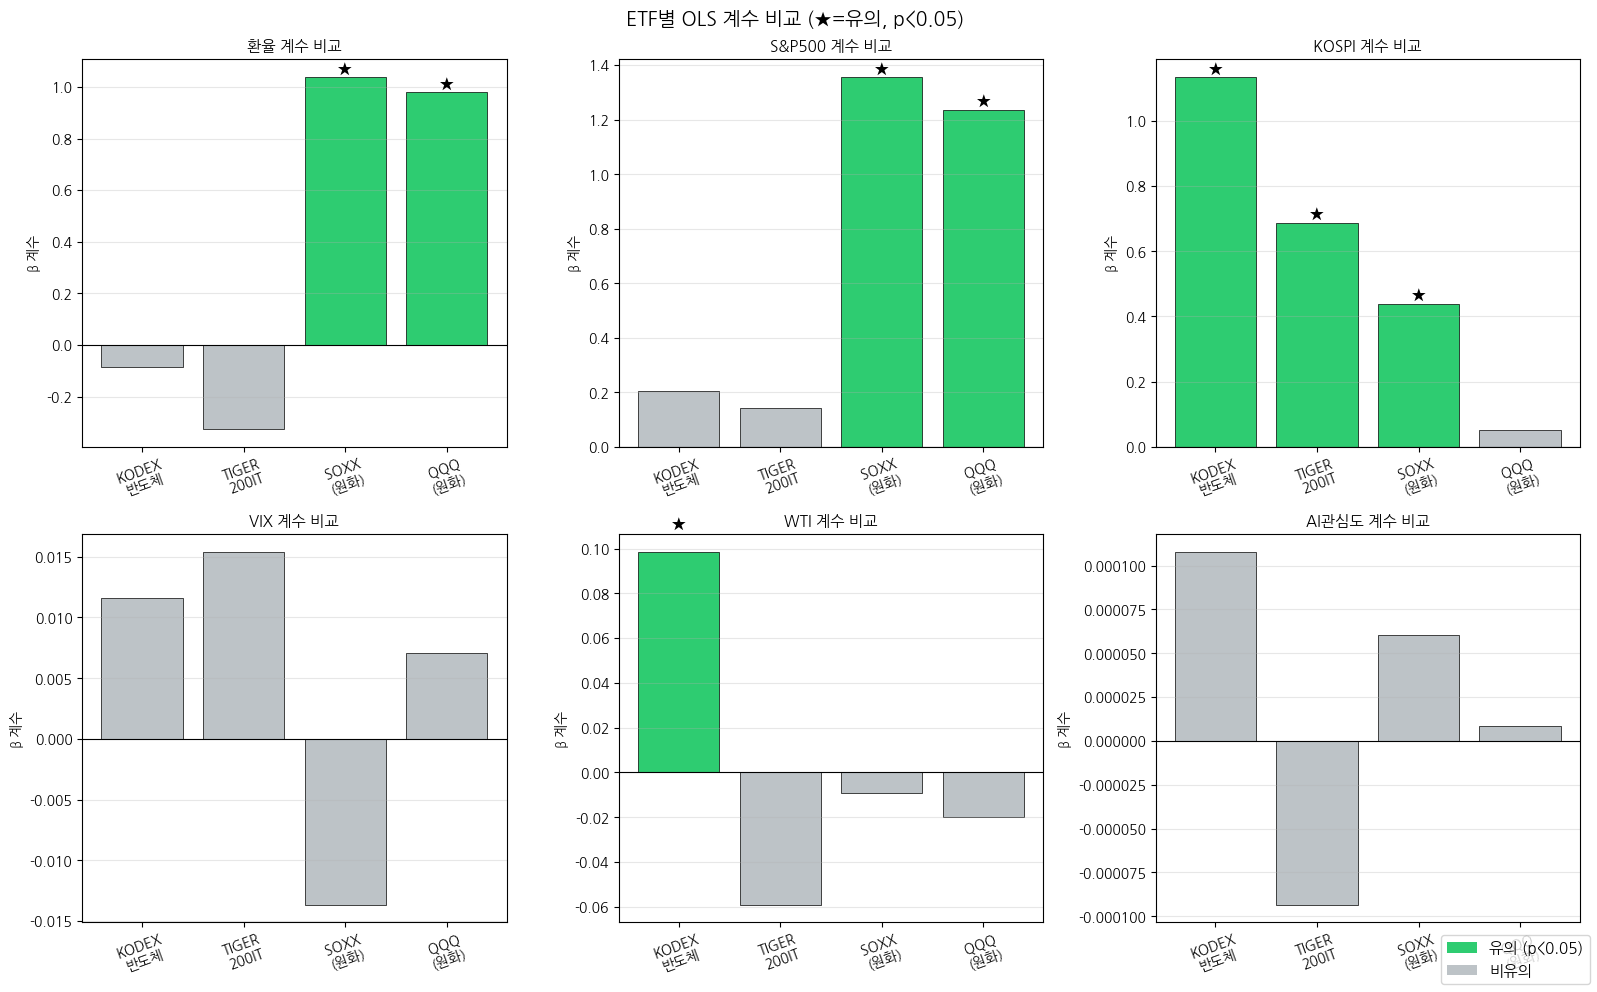

✅ OLS 계수 비교 저장 완료


In [ ]:
# OLS 계수 비교 (results 재사용, 6개 변수 전체)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

variables  = ['USDKRW_ret','SP500_ret','KOSPI_ret','VIX_ret','WTI_ret','AI_interest']
var_labels = ['환율','S&P500','KOSPI','VIX','WTI','AI관심도']
etf_names  = ['KODEX 반도체','TIGER 200IT','SOXX (원화)','QQQ (원화)'] # Updated to match results dict keys
etf_labels = ['KODEX\n반도체', 'TIGER\n200IT', 'SOXX\n(원화)', 'QQQ\n(원화)']

x = range(len(etf_names))

for ax, var, label in zip(axes.flatten(), variables, var_labels):
    coefs  = [results[e]['model'].params[var] for e in etf_names] # Access 'model' key
    pvals  = [results[e]['model'].pvalues[var] for e in etf_names] # Access 'model' key
    colors = ['#2ECC71' if p < 0.05 else '#BDC3C7' for p in pvals]

    # bar 그릴 때
    bars = ax.bar(etf_labels, coefs, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{label} 계수 비교', fontsize=11)
    ax.set_ylabel('β 계수')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

    for bar, p in zip(bars, pvals):
        if p < 0.05:
            ypos = bar.get_height() + 0.01 if bar.get_height() >= 0 else bar.get_height() - 0.05
            ax.text(bar.get_x() + bar.get_width()/2, ypos,
                    '★', ha='center', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ECC71', label='유의 (p<0.05)'),
    Patch(facecolor='#BDC3C7', label='비유의')
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=11)
plt.suptitle('ETF별 OLS 계수 비교 (★=유의, p<0.05)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/데이터마이닝/ols_coef_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ OLS 계수 비교 저장 완료')